In [1]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/processed/modeling_datset.csv")

model_df = pd.read_csv(DATA_PATH)

train_df = model_df[model_df["issue_year"] <= 2015].copy()

validation_df = model_df[
    model_df["issue_year"].between(2016,2017)
].copy()

test_df = model_df[
    model_df["issue_year"] == 2018
].copy()

target_column = "default_flag"

feature_columns = [
    column for column in model_df.columns
    if column != target_column
]

x_train  = train_df[feature_columns]
y_train = train_df[target_column].astype("int8")

x_validation = validation_df[feature_columns]
y_validation = validation_df[target_column].astype("int8")

x_test = test_df[feature_columns]
y_test = test_df[target_column].astype("int8")

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (829355, 13)
Validation: (462426, 13)
Test: (56318, 13)


In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_features = x_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = x_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(strategy="most_frequent"),
                    ),
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=True,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Tree preprocessor created successfully")

Numeric features: ['loan_amnt', 'term_months', 'int_rate', 'emp_length_years', 'annual_inc', 'issue_year', 'dti']
Categorical features: ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose']
Tree preprocessor created successfully


In [3]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=8,
                min_samples_leaf=100,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

In [4]:
decision_tree_model.fit(x_train, y_train)

tree_predictions = decision_tree_model.predict(x_validation)
tree_probabilities = decision_tree_model.predict_proba(
    x_validation
)[:, 1]

print("Decision tree trained successfuly")
print("Predicted classes:", set(tree_predictions))

Decision tree trained successfuly
Predicted classes: {np.int8(0), np.int8(1)}


In [5]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=50,
                max_depth=12,
                min_samples_leaf=100,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            ),
        ),
    ]
)

In [6]:
y_train = train_df[target_column].to_numpy().ravel()
y_validation = validation_df[target_column].to_numpy().ravel()
y_test = test_df[target_column].to_numpy().ravel()

In [7]:
random_forest_model.fit(x_train, y_train)

forest_predictions = random_forest_model.predict(x_validation)
forest_probabilities = random_forest_model.predict_proba(
    x_validation
)[:, 1]

print("Random Forest trained successfully.")
print("Predicted classes:", set(forest_predictions))

Random Forest trained successfully.
Predicted classes: {np.int64(0), np.int64(1)}


In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

def evaluate_model(name, y_true, predictions, probabilities):
    return{
        "model": name,
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(
            y_true, predictions, zero_division=0
        ),
        "recall": recall_score(
            y_true, predictions, zero_division=0
        ),
        "f1": f1_score(
            y_true, predictions, zero_division=0
        ),
        "roc_auc": roc_auc_score(y_true, probabilities),
    }

tree_results = pd.DataFrame([
    evaluate_model(
        "Decision tree",
        y_validation,
        tree_predictions,
        tree_probabilities,
    ),
    evaluate_model(
        "Random forest",
        y_validation,
        forest_predictions,
        forest_probabilities,
    ),
])

display(tree_results.round(4))

,model,accuracy,precision,recall,f1,roc_auc
0,Decision tree,0.6208,0.3405,0.6749,0.4526,0.6944
1,Random forest,0.6328,0.3482,0.6664,0.4574,0.6989


In [9]:
print("Feature columns:")
print(feature_columns)

print("\nTarget in feature columns:")
print(target_column in feature_columns)

print("\nX validation shape:", x_validation.shape)
print("\nY_validation shape:", y_validation.shape)

print("\nModeling dataset columns:")
print(model_df.columns.tolist())

print("\nPrediction agreement:")
print((forest_predictions == y_validation).mean())

print("\nConfusion Matrix:")
print(
    pd.crosstab(
        y_validation,
        forest_predictions,
        rownames=["actual"],
        colnames=["predicted"]
    )
)

Feature columns:
['loan_amnt', 'term_months', 'int_rate', 'grade', 'sub_grade', 'emp_length_years', 'home_ownership', 'annual_inc', 'verification_status', 'issue_year', 'purpose', 'dti']

Target in feature columns:
False

X validation shape: (462426, 12)

Y_validation shape: (462426,)

Modeling dataset columns:
['loan_amnt', 'term_months', 'int_rate', 'grade', 'sub_grade', 'emp_length_years', 'home_ownership', 'annual_inc', 'verification_status', 'issue_year', 'purpose', 'dti', 'default_flag']

Prediction agreement:
0.6327628636798104

Confusion Matrix:
predicted       0       1
actual                   
0          221025  133980
1           35840   71581


In [10]:
assert "default_flag" not in feature_columns
assert "outcome_group" not in feature_columns
assert "loan_status" not in feature_columns

print("No obvious target leakage in feature columns.")

No obvious target leakage in feature columns.


#### After correcting target leakage, model performance became realistic. Random forest currently provides the strongest balance, with an F1-score of 0.4574 and ROC-AUC of 0.6989. Logistic regression has higher recall, while the decision tree has the lowest overall balance.

In [11]:
tree_test_predictions = decision_tree_model.predict(x_test)
tree_test_probabilities = decision_tree_model.predict_proba(
    x_test
)[:, 1]

forest_test_predictions = random_forest_model.predict(x_test)
forest_test_probabilities = random_forest_model.predict_proba(
    x_test
)[:, 1]

print("Test predictions generated.")

Test predictions generated.


In [12]:
test_results = pd.DataFrame([
    evaluate_model(
        "Decison tree - 2018 test",
        y_test,
        tree_test_predictions,
        forest_test_probabilities,
    ),
    evaluate_model(
        "Random forest - 2018 test",
        y_test,
        forest_test_predictions,
        forest_test_probabilities,
    )
])

display(test_results.round(4))

,model,accuracy,precision,recall,f1,roc_auc
0,Decison tree - 2018 test,0.5948,0.2335,0.6882,0.3486,0.6912
1,Random forest - 2018 test,0.6206,0.2428,0.6645,0.3557,0.6912


#### On the untouched 2018 test set, random forest is the stronger balanced candidate with an F1-score of 0.3557. The decision tree provides slightly higher recall at 0.6882, but has lower precision and F1-score. Both models achieve a ROC-AUC of 0.6912. The lower test performance compared with validation demonstrates why final evaluation must use unseen data.

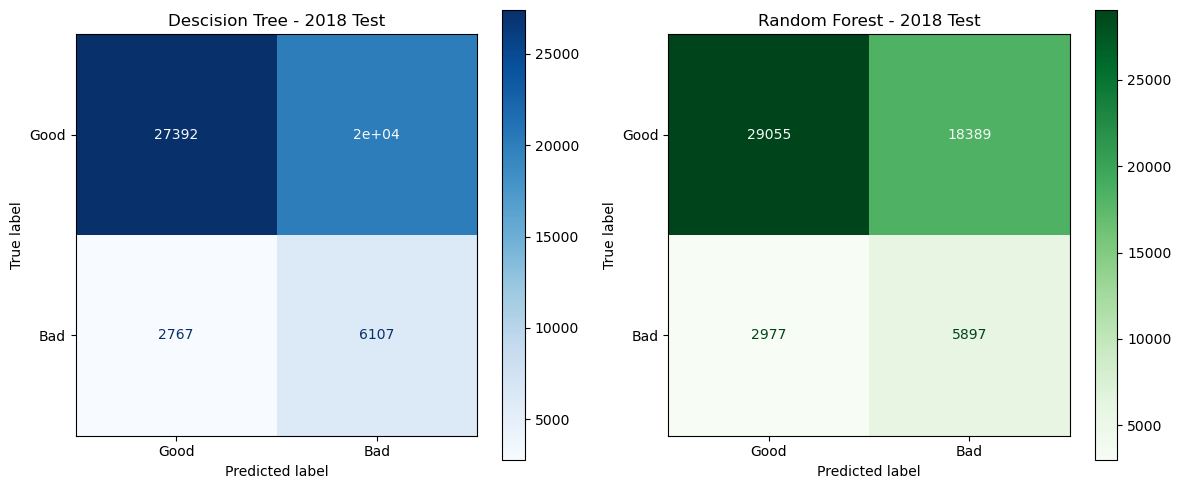

In [13]:
from sklearn.metrics import(
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(12,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_test_predictions,
    display_labels=["Good", "Bad"],
    cmap="Blues",
    ax=axes[0],
)

axes[0].set_title("Descision Tree - 2018 Test")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    forest_test_predictions,
    display_labels=["Good", "Bad"],
    cmap="Greens",
    ax=axes[1],
)

axes[1].set_title("Random Forest - 2018 Test")

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

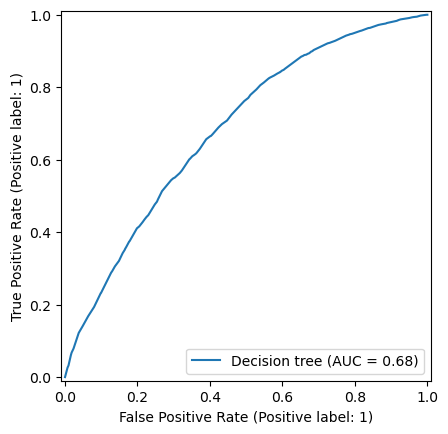

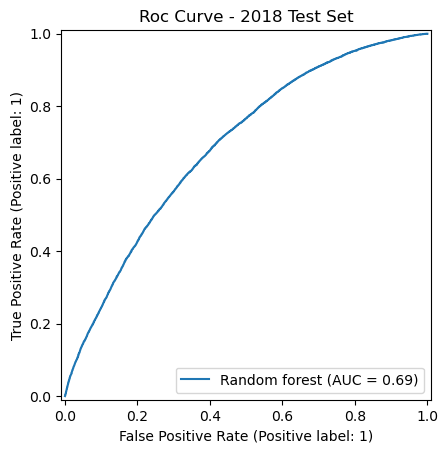

In [14]:
plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test,
    tree_test_probabilities,
    name="Decision tree",
)

RocCurveDisplay.from_predictions(
    y_test,
    forest_test_probabilities,
    name="Random forest"
)

plt.title("Roc Curve - 2018 Test Set")
plt.show()

Tree AUC: 0.6840063303603302
Forest AUC: 0.6912411958407789


<Figure size 800x600 with 0 Axes>

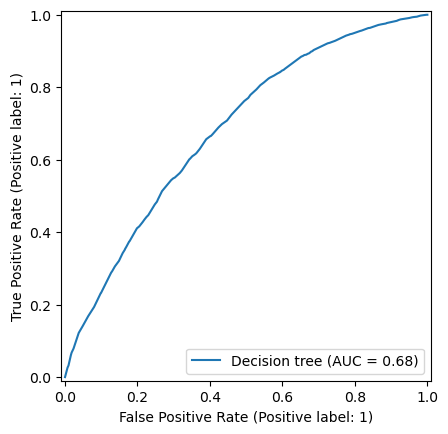

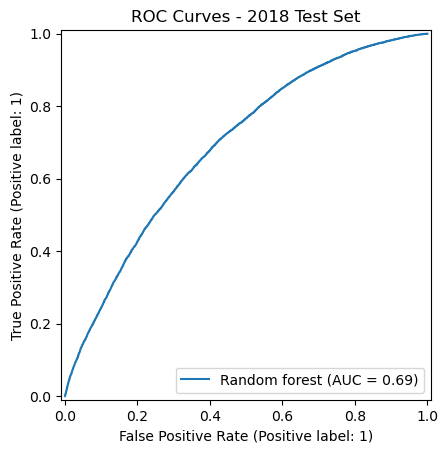

In [15]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

print("Tree AUC:", roc_auc_score(y_test, tree_test_probabilities))
print("Forest AUC:", roc_auc_score(y_test, forest_test_probabilities))

plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test,
    tree_test_probabilities,
    name="Decision tree"
)

RocCurveDisplay.from_predictions(
    y_test,
    forest_test_probabilities,
    name="Random forest"
)

plt.title("ROC Curves - 2018 Test Set")
plt.show()

In [16]:
test_results = pd.DataFrame([
    evaluate_model(
        "Decision tree - 2018 test",
        y_test,
        tree_test_predictions,
        tree_test_probabilities,
    ),
    evaluate_model(
        "Random forest - 2018 test",
        y_test,
        forest_test_predictions,
        forest_test_probabilities,
    ),
])

display(test_results.round(4))

,model,accuracy,precision,recall,f1,roc_auc
0,Decision tree - 2018 test,0.5948,0.2335,0.6882,0.3486,0.6840
1,Random forest - 2018 test,0.6206,0.2428,0.6645,0.3557,0.6912


<Figure size 800x600 with 0 Axes>

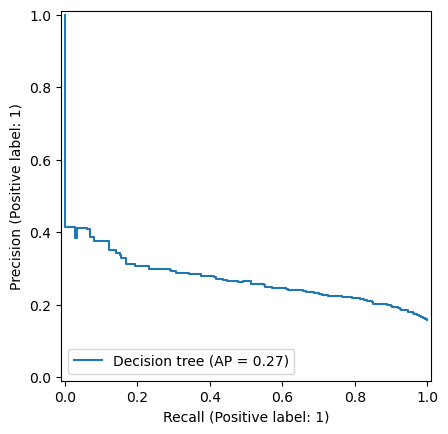

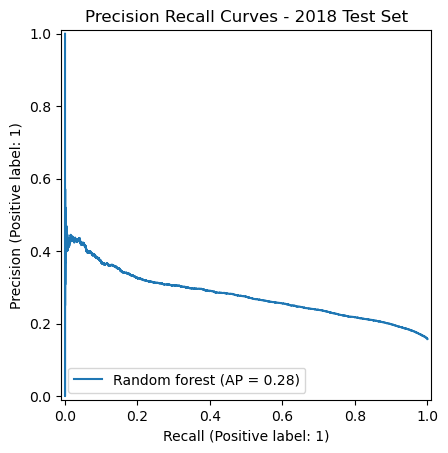

In [17]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(8,6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    tree_test_probabilities,
    name="Decision tree"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    forest_test_probabilities,
    name="Random forest"
)

plt.title("Precision Recall Curves - 2018 Test Set")
plt.show()

In [18]:
fitted_preprocessor = random_forest_model.named_steps["preprocessor"]
forest_classifier = random_forest_model.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()
feature_importances = forest_classifier.feature_importances_

importance_df = (
    pd.DataFrame({
      "feature": feature_names,
        "importances": feature_importances,
    })
    .sort_values("importances", ascending=False)
)

display(importance_df.head(20))

,feature,importances
2,numeric__int_rate,0.298360
1,numeric__term_months,0.186896
7,categorical__grade_A,0.082111
8,categorical__grade_B,0.052576
11,categorical__grade_E,0.044727
6,numeric__dti,0.038923
10,categorical__grade_D,0.029133
4,numeric__annual_inc,0.024888
0,numeric__loan_amnt,0.024375
9,categorical__grade_C,0.020708


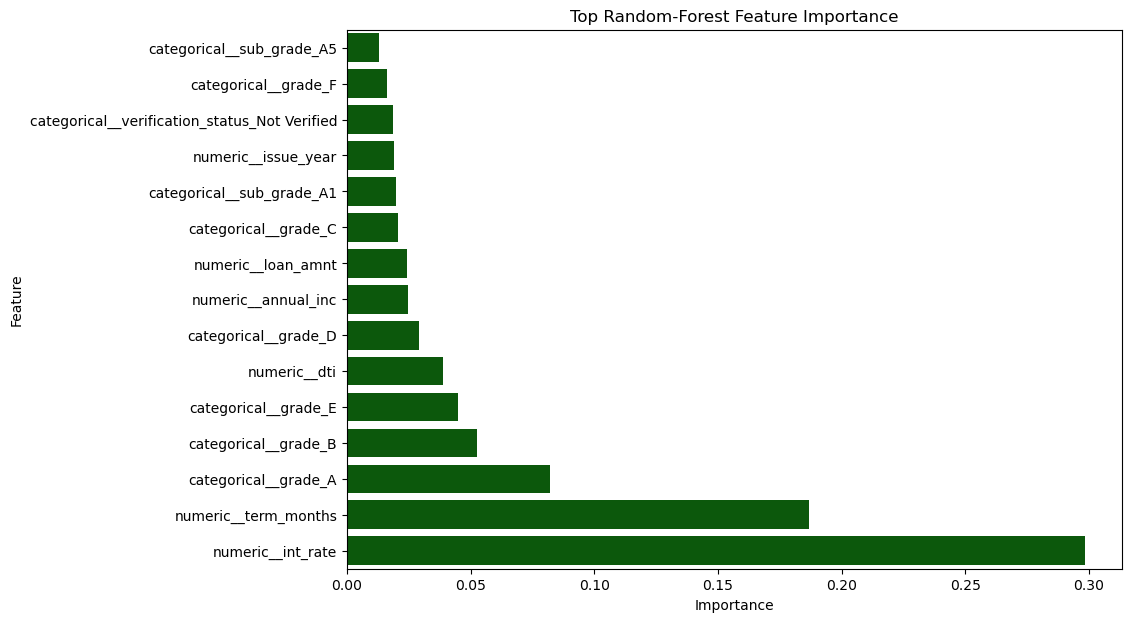

In [19]:
import seaborn as sns
top_features = importance_df.head(15).sort_values("importances")

plt.figure(figsize=(10,7))
sns.barplot(
    data=top_features,
    x="importances",
    y="feature",
    color="darkgreen"
)

plt.title("Top Random-Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

#### Random-forest feature importance identifies which transformed variables were most useful for reducing impurity across the trees. It indicates predictive contribution, not causation or direction. For example, `categorical__grade_A` being important does not mean Grade A increases risk; it means that category helps the model separate outcomes.

In [20]:
def original_feature(transformed_name):
    raw_name = transformed_name.split("__", 1)[-1]

    if transformed_name.startswith("numeric__"):
        return raw_name
        
    for feature in categorical_features:
        if raw_name == feature or raw_name.startswith(f"{feature}_"):
            return feature

    return raw_name

importance_df["original_feature"] = (
    importance_df["feature"].apply(original_feature)
)

aggregated_importance = (
    importance_df.groupby("original_feature")["importances"]
    .sum()
    .sort_values(ascending=False)
    .to_frame()
)

display(aggregated_importance)

,importances
original_feature,
int_rate,0.298360
grade,0.246615
term_months,0.186896
sub_grade,0.106645
dti,0.038923
annual_inc,0.024888
loan_amnt,0.024375
home_ownership,0.023957
verification_status,0.021685


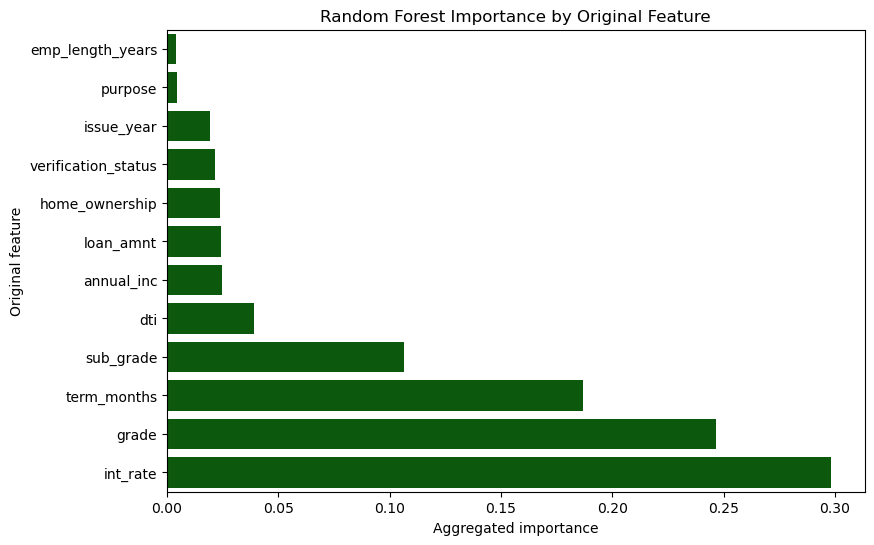

In [21]:
aggregated_plot = aggregated_importance.sort_values("importances")

plt.figure(figsize=(9,6))
sns.barplot(
    data=aggregated_plot.reset_index(),
    x="importances",
    y="original_feature",
    color="darkgreen"
)

plt.title("Random Forest Importance by Original Feature")
plt.xlabel("Aggregated importance")
plt.ylabel("Original feature")
plt.show()

### Explainability Finding

The random forest assigns the greatest aggregated importance to interest rate, grade, loan term, and sub-grade. Interest rate contributes 29.84%, grade 24.66%, term 18.69%, and sub-grade 10.66%. Grade and sub-grade are related credit-risk variables, so their combined contribution is approximately 35.33%.

These importances describe predictive usefulness in the fitted forest, not causation or the direction of risk. They should not be interpreted as evidence that a feature independently causes default.

In [26]:
import numpy as np
error_analysis = x_test.copy()

error_analysis["actual"] = y_test
error_analysis["predicted"] = forest_test_predictions
error_analysis["probability_bad"] = forest_test_probabilities

error_analysis["error_type"] = np.select(
    [
        (error_analysis["actual"] == 1) & (error_analysis["predicted"] == 1),
        (error_analysis["actual"] == 0) & (error_analysis["predicted"] == 0),
        (error_analysis["actual"] == 0) & (error_analysis["predicted"] == 1),
        (error_analysis["actual"] == 1) & (error_analysis["predicted"] == 0),
    ],
    ["True Positive", "True Negative", "False Positive", "False Negative"],
    default="Unknown",
)

display(error_analysis["error_type"].value_counts())

error_type
True Negative     29055
False Positive    18389
True Positive      5897
False Negative     2977
Name: count, dtype: int64

In [27]:
grade_error_summary = (
    error_analysis
    .groupby("grade")["error_type"]
    .value_counts()
    .unstack(fill_value=0)
)

display(grade_error_summary)

error_type,False Negative,False Positive,True Negative,True Positive
grade,,,,
A,661,0,12159,0
B,1679,630,12818,106
C,628,8055,3949,2123
D,9,7048,129,2489
E,0,2149,0,883
F,0,420,0,240
G,0,87,0,56


In [30]:
grade_error_rates = (
    error_analysis
    .groupby("grade")
    .agg(
        total_loans = ("actual", "size"),
        false_positive=("error_type", lambda values: (values == "False Positive").sum()),
        false_negative=("error_type", lambda values: (values == "False Negative").sum()),
        actual_bad_loans=("actual", "sum"),
    )
)

grade_error_rates["false_postive_rate"] = (
    grade_error_rates["false_positive"]
    / grade_error_rates["total_loans"]
)

grade_error_rates["false_negative_rates"] = (
    grade_error_rates["false_negative"]
    / grade_error_rates["actual_bad_loans"]
)

display(grade_error_rates.round(4))

,total_loans,false_positive,false_negative,actual_bad_loans,false_postive_rate,false_negative_rates
grade,,,,,,
A,12820,0,661,661,0.0000,1.0000
B,15233,630,1679,1785,0.0414,0.9406
C,14755,8055,628,2751,0.5459,0.2283
D,9675,7048,9,2498,0.7285,0.0036
E,3032,2149,0,883,0.7088,0.0000
F,660,420,0,240,0.6364,0.0000
G,143,87,0,56,0.6084,0.0000


### Grade-Level Error Finding

The error analysis shows different error patterns across grades. Grades A and B have very high false-negative rates, meaning the model misses many bad loans in these groups. Grades C through G have high false-positive rates, meaning the model frequently flags good loans as risky.

This suggests that the model is strongly influenced by grade-level risk patterns but does not separate borderline cases reliably within each grade. The results support using probability thresholds and segment-specific monitoring rather than relying only on the default classification threshold.

In [37]:
error_analysis["dti_band"] = pd.cut(
    error_analysis["dti"].where(error_analysis["dti"] < 100),
    bins=[-np.inf, 10, 20, 30, np.inf],
    labels=["0-10", "10-20", "20-30", "30+"],
)

error_analysis["dti_band"] = error_analysis["dti_band"].cat.add_categories("Special/Invalid")
error_analysis["dti_band"] = error_analysis["dti_band"].fillna("Special/Invalid")

dti_error_summary = (
    error_analysis
    .groupby("dti_band", observed=False)["error_type"]
    .value_counts()
    .unstack(fill_value=0)
)

display(dti_error_summary)

error_type,False Negative,False Positive,True Negative,True Positive
dti_band,,,,
0-10,905,2831,8579,1131
10-20,1140,6319,12550,1850
20-30,666,6015,5865,1792
30+,257,3066,1962,1077
Special/Invalid,9,158,99,47


In [36]:
print(error_analysis.columns.tolist())

['loan_amnt', 'term_months', 'int_rate', 'grade', 'sub_grade', 'emp_length_years', 'home_ownership', 'annual_inc', 'verification_status', 'issue_year', 'purpose', 'dti', 'actual', 'predicted', 'probability_bad', 'error_type']


In [38]:
dti_error_rates = (
    error_analysis
    .groupby("dti_band", observed=False)
    .agg(
        total_loans=("actual", "size"),
        false_positives=("error_type", lambda values: (values == "False Positive").sum()),
        false_negatives=("error_type", lambda values: (values == "False Negative").sum()),
        actual_bad_loans=("actual", "sum"),
    )
)

dti_error_rates["false_positive_rate"] = (
    dti_error_rates["false_positives"]
    / dti_error_rates["total_loans"]
)

dti_error_rates["false_negative_rate"] = (
    dti_error_rates["false_negatives"]
    / dti_error_rates["actual_bad_loans"]
)

display(dti_error_rates.round(4))

,total_loans,false_positives,false_negatives,actual_bad_loans,false_positive_rate,false_negative_rate
dti_band,,,,,,
0-10,13446,2831,905,2036,0.2105,0.4445
10-20,21859,6319,1140,2990,0.2891,0.3813
20-30,14338,6015,666,2458,0.4195,0.2710
30+,6362,3066,257,1334,0.4819,0.1927
Special/Invalid,313,158,9,56,0.5048,0.1607


### DTI-Level Error Finding

The model becomes increasingly conservative as DTI rises. False-positive rates increase from 21.05% in the 0–10 band to 48.19% in the 30+ band, while false-negative rates decrease from 44.45% to 19.27%.

This indicates a trade-off: the model catches more bad loans among high-DTI borrowers but incorrectly flags more good loans. The Special/Invalid group is small and should be treated as a data-quality segment rather than a normal risk band.

In [39]:
term_error_summary = (
    error_analysis
    .groupby("term_months")["error_type"]
    .value_counts()
    .unstack(fill_value=0)
)

display(term_error_summary)

error_type,False Negative,False Positive,True Negative,True Positive
term_months,,,,
36,2617,9529,26275,2851
60,360,8860,2780,3046


In [40]:
term_error_rates = (
    error_analysis
    .groupby("term_months")
    .agg(
        total_loans=("actual", "size"),
        false_positives=("error_type", lambda values: (values == "False Positive").sum()),
        false_negatives=("error_type", lambda values: (values == "False Negative").sum()),
        actual_bad_loans=("actual", "sum"),
    )
)

term_error_rates["false_positive_rate"] = (
    term_error_rates["false_positives"]
    / term_error_rates["total_loans"]
)

term_error_rates["false_negative_rate"] = (
    term_error_rates["false_negatives"]
    / term_error_rates["actual_bad_loans"]
)

display(term_error_rates.round(4))

,total_loans,false_positives,false_negatives,actual_bad_loans,false_positive_rate,false_negative_rate
term_months,,,,,,
36,41272,9529,2617,5468,0.2309,0.4786
60,15046,8860,360,3406,0.5889,0.1057


### Loan-Term Error Finding

The model behaves differently by loan term. For 36-month loans, the false-negative rate is 47.86%, meaning many bad loans are missed. For 60-month loans, the false-positive rate increases to 58.89%, while the false-negative rate falls to 10.57%.

This suggests that the model treats longer-term loans as higher risk. It detects more bad loans in this segment but also flags many good loans incorrectly.

In [41]:
error_analysis["income_band"] = pd.cut(
    error_analysis["annual_inc"],
    bins=[-np.inf, 30000, 60000, 100000, np.inf],
    labels=["Below 30k", "30k-60k", "60k-100k", "100k+"],
)

income_error_summary = (
    error_analysis
    .groupby("income_band", observed=False)["error_type"]
    .value_counts()
    .unstack(fill_value=0)
)

display(income_error_summary)

error_type,False Negative,False Positive,True Negative,True Positive
income_band,,,,
Below 30k,347,1747,1871,709
30k-60k,1011,7161,9292,2439
60k-100k,1007,6263,10781,1909
100k+,612,3218,7111,840


In [42]:
income_error_rates = (
    error_analysis
    .groupby("income_band", observed=False)
    .agg(
        total_loans=("actual", "size"),
        false_positives=("error_type", lambda values: (values == "False Positive").sum()),
        false_negatives=("error_type", lambda values: (values == "False Negative").sum()),
        actual_bad_loans=("actual", "sum"),
    )
)

income_error_rates["false_positive_rate"] = (
    income_error_rates["false_positives"]
    / income_error_rates["total_loans"]
)

income_error_rates["false_negative_rate"] = (
    income_error_rates["false_negatives"]
    / income_error_rates["actual_bad_loans"]
)

display(income_error_rates.round(4))

,total_loans,false_positives,false_negatives,actual_bad_loans,false_positive_rate,false_negative_rate
income_band,,,,,,
Below 30k,4674,1747,347,1056,0.3738,0.3286
30k-60k,19903,7161,1011,3450,0.3598,0.2930
60k-100k,19960,6263,1007,2916,0.3138,0.3453
100k+,11781,3218,612,1452,0.2732,0.4215


### Income-Level Error Finding

The model produces the highest false-positive rate for borrowers earning below 30k, while the 100k+ group has the highest false-negative rate. This suggests that the model is more cautious with lower-income borrowers but may under-identify risk among higher-income borrowers.

These results should be interpreted as model-behaviour patterns, not evidence that income independently causes default.